# Banking Product Propensity Modeling — end-to-end demo

**Business question:** Given a customer's transaction history, which anonymized banking product might they adopt next month?

This notebook demonstrates the complete workflow on deterministic synthetic data, so it runs without downloading private or large banking files. It treats Logistic Regression, Random Forest, and Gradient Boosting as the main data-science baselines. A transaction transformer is an advanced experiment, not the starting point.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

from bankrec.data import prepare
from bankrec.experiment import run_experiment
from bankrec.synthetic import make_synthetic_banking_data

ARTIFACTS = Path('../artifacts/notebook-demo')

C:\Users\hp\Downloads\project 2\banking-product-recommender\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load a safe, reproducible dataset

The generator creates fictional customers, transaction types, signed amounts, dates, and four binary next-month outcomes. The random seed makes every run reproducible.

In [2]:
transactions, targets, client_folds = make_synthetic_banking_data(
    clients=300, months=8, seed=42
)
print(f'{len(transactions):,} transactions | {len(targets):,} customer-month targets')
transactions.head()

10,709 transactions | 2,400 customer-month targets


,client_id,event_time,event_type,amount
0,demo-0000,2023-01-12 01:00:00,6,15.535209
1,demo-0000,2023-01-22 02:00:00,1,-122.931474
2,demo-0000,2023-01-22 03:00:00,2,-65.049852
3,demo-0000,2023-01-08 04:00:00,1,28.541333
4,demo-0000,2023-01-12 05:00:00,1,-12.439115


## 2. Exploratory analysis

Product uptake is imbalanced, which is why accuracy is not the main metric. Transaction volume and amount behavior also vary across customers.

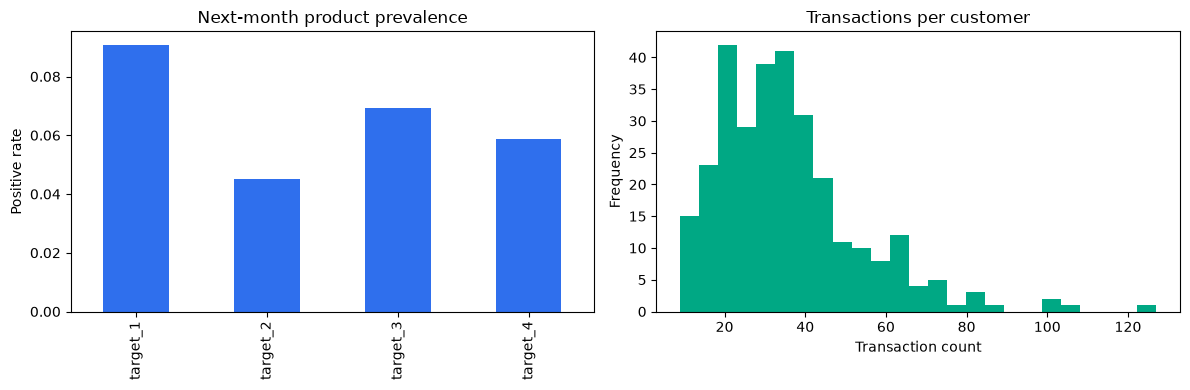

In [3]:
target_columns = [f'target_{i}' for i in range(1, 5)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
targets[target_columns].mean().rename('prevalence').plot.bar(ax=axes[0], color='#2f6fed')
axes[0].set_title('Next-month product prevalence')
axes[0].set_ylabel('Positive rate')
transactions.groupby('client_id').size().plot.hist(ax=axes[1], bins=25, color='#00a884')
axes[1].set_title('Transactions per customer')
axes[1].set_xlabel('Transaction count')
plt.tight_layout()

## 3. Leakage-aware feature engineering

For each reporting month, `prepare` keeps only transactions available by that cutoff. It builds tabular summaries such as activity, amount, recency, credit share, and event-type counts, plus padded transaction sequences for the transformer.

In [4]:
data = prepare(transactions, targets, client_folds, max_events=32)
print(data.baseline_features.shape, data.event_types.shape, data.labels.shape)
data.baseline_features.describe().T

(2400, 18) (2400, 33) (2400, 4)


,count,mean,std,min,25%,50%,75%,max
transaction_count,2400.0,17.422917,10.147551,1.000000,9.000000,16.000000,27.000000,32.000000
total_amount,2400.0,-239.384985,250.217045,-1247.465137,-386.551262,-211.706243,-59.156771,1006.927772
total_absolute_amount,2400.0,654.086579,416.005641,2.654130,306.144297,600.441982,976.935655,2723.366967
mean_amount,2400.0,-13.961969,17.786117,-208.244295,-21.482553,-13.846057,-6.123527,115.489448
std_amount,2400.0,43.962557,21.802351,0.000000,32.556767,40.522672,53.526504,283.035592
credit_share,2400.0,0.314449,0.156448,0.000000,0.227273,0.312500,0.400000,1.000000
recent_30d_count,2400.0,4.361250,2.949753,0.000000,2.000000,4.000000,6.000000,23.000000
recent_90d_count,2400.0,11.422083,6.871883,1.000000,6.000000,10.000000,15.000000,32.000000
days_since_last,2400.0,10.161892,6.299140,1.500000,5.822917,7.958333,12.958333,30.958333
unique_event_types,2400.0,6.378750,1.923584,1.000000,5.000000,7.000000,8.000000,8.000000


## 4. Train baselines and the transformer experiment

The split is chronological: earlier reporting months train the models, the second-latest month validates them, and the latest month is the untouched test set. This better represents future performance and prevents later target months from leaking into training.

The transformer consumes ordered transaction type, amount, and recency. Its BERT-style encoder is initialized from scratch; it is not a pretrained language model.

In [5]:
report = run_experiment(
    data, epochs=1, batch_size=64, split_strategy='time',
    output_dir=ARTIFACTS, dataset_name='synthetic demo'
)
report['split']

'time-based: through 2023-06 train, 2023-07 validation, 2023-08 test'

## 5. Evaluate with rare-event and ranking metrics

Average precision summarizes the precision-recall trade-off and should be read beside prevalence. Hit@1 and recall@2 are calculated only for customer-months with at least one recorded uptake. Lift measures how concentrated positives are in the highest-ranked 10%.

In [6]:
labels = report['model_labels']
summary = pd.DataFrame([
    {
        'model': labels[name],
        'macro_average_precision': values['test']['macro_average_precision'],
        'buyer_hit_at_1': values['test']['hit_at_1_among_buyers'],
        'buyer_recall_at_2': values['test']['recall_at_2_among_buyers'],
    }
    for name, values in report['models'].items()
]).set_index('model')
summary.style.format('{:.3f}')

,macro_average_precision,buyer_hit_at_1,buyer_recall_at_2
model,,,
Logistic Regression,0.312,0.532,0.677
Random Forest,0.297,0.477,0.629
Gradient Boosting,0.254,0.450,0.602
Transaction Transformer,0.174,0.505,0.575


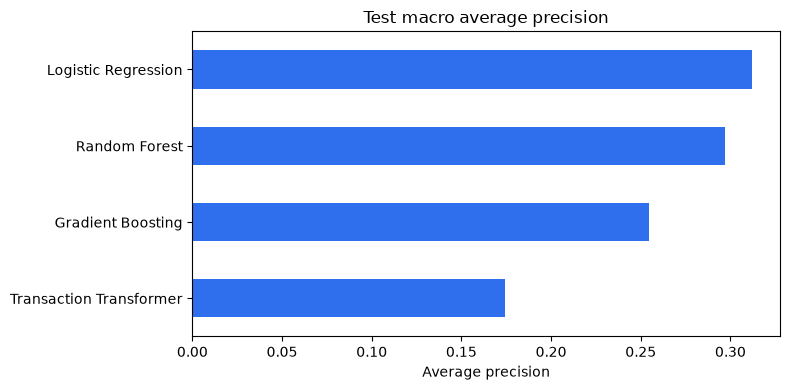

In [7]:
summary['macro_average_precision'].sort_values().plot.barh(
    figsize=(8, 4), color='#2f6fed', title='Test macro average precision'
)
plt.xlabel('Average precision')
plt.ylabel('')
plt.tight_layout()

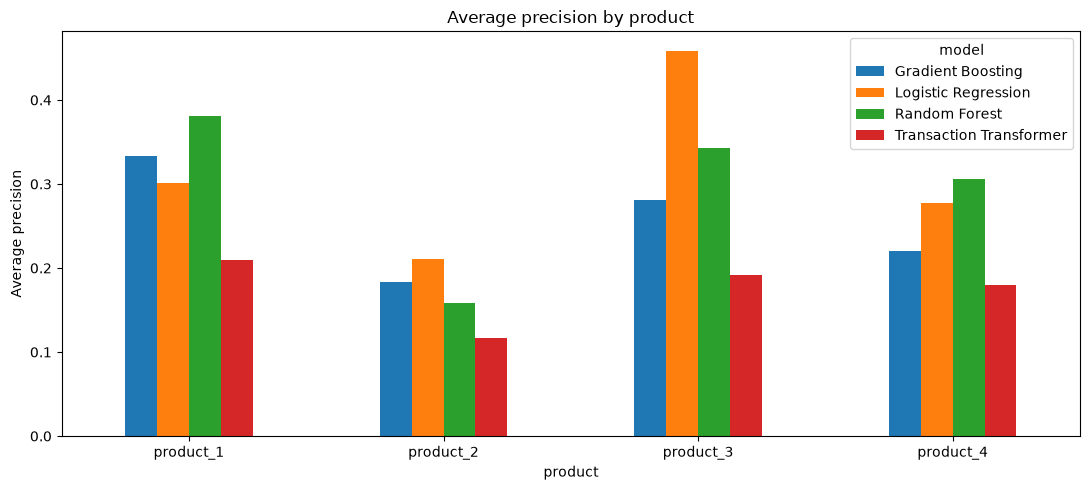

In [8]:
rows = []
for model_name, values in report['models'].items():
    for product, metrics in values['test']['per_product'].items():
        rows.append({
            'model': labels[model_name], 'product': product,
            'prevalence': metrics['prevalence'],
            'average_precision': metrics['average_precision'],
            'top_10pct_lift': metrics['lift']['top_10pct'],
        })
product_results = pd.DataFrame(rows)
product_results.pivot(index='product', columns='model', values='average_precision').plot.bar(
    figsize=(11, 5), title='Average precision by product'
)
plt.ylabel('Average precision')
plt.xticks(rotation=0)
plt.tight_layout()

## 6. Interpret tabular signals

Global feature importance helps explain which engineered behaviors the Random Forest used. These are associations, not causal effects or individual explanations.

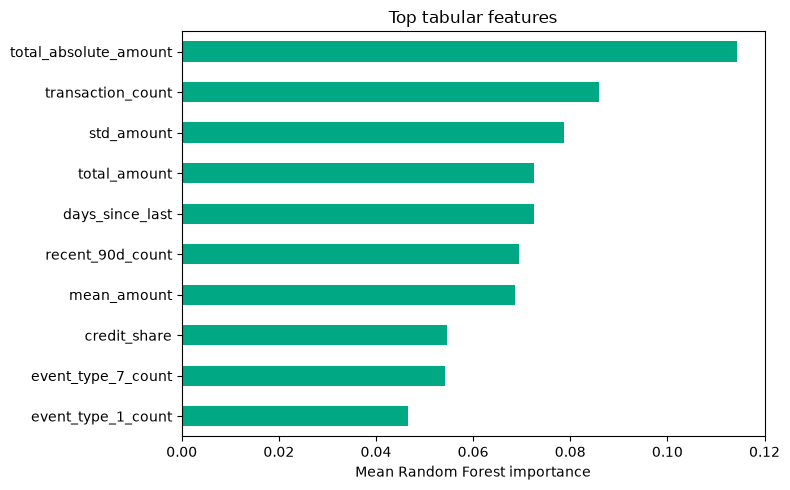

In [9]:
importance = pd.read_csv(ARTIFACTS / 'feature_importance.csv')
top = importance.groupby('feature')['random_forest_importance'].mean().nlargest(10).sort_values()
top.plot.barh(figsize=(8, 5), color='#00a884', title='Top tabular features')
plt.xlabel('Mean Random Forest importance')
plt.ylabel('')
plt.tight_layout()

## 7. Business interpretation and limitations

The practical output is a ranked list of anonymized products, allowing a team to compare top-k targeting strategies rather than forcing a yes/no decision. The transformer is useful only if it improves future-period metrics enough to justify its added complexity.

Important limitations: this predicts observed uptake, not causal offer response; synthetic results are only a runnable demonstration; MBD product identities are anonymized; rare outcomes require uncertainty checks; production use would require probability calibration, fairness/privacy review, drift monitoring, and approved business rules.